In [24]:
import os
import matplotlib.pyplot as plt
from matplotlib import rcParams
from glob import glob as gg
from keras.models import Model
from collections import Counter
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, max, min, udf
from pyspark.sql.types import StructField, StructType, StringType, ArrayType, IntegerType, FloatType

In [46]:
spark = SparkSession.builder. \
			appName("LSTMJsonExtractor"). \
			config("spark.driver.port", "5432"). \
			config("spark.blockManager.port", "4321"). \
			config("spark.driver.memory", "16g"). \
			config("spark.executor.memory", "16g"). \
			config("spark.driver.maxResultSize", "16g"). \
			getOrCreate()

java.net.SocketTimeoutException: Accept timed out
	at java.base/java.net.PlainSocketImpl.socketAccept(Native Method)
	at java.base/java.net.AbstractPlainSocketImpl.accept(AbstractPlainSocketImpl.java:474)
	at java.base/java.net.ServerSocket.implAccept(ServerSocket.java:565)
	at java.base/java.net.ServerSocket.accept(ServerSocket.java:533)
	at org.apache.spark.security.SocketAuthServer$$anon$1.run(SocketAuthServer.scala:65)


In [48]:
dpi = 200 # 200-300 as per guidelines
maxpix = 670  # max pixels of plot
width = maxpix / dpi  # max allowed width
rcParams.update({'axes.labelsize': 'large', 'axes.titlesize': 'large',  # the size of labels and title
                 'xtick.labelsize': 'large', 'ytick.labelsize': 'large',  # the size of the axes ticks
                 'legend.fontsize': 'x-small', 'legend.frameon': False,  # legend font size, no frame
                 'legend.facecolor': 'none', 'legend.handletextpad': 0.25,
                 # legend no background colour, separation from label to point
                 'font.serif': ['Arial'],  # default fonts to try and use
                 'font.family': 'serif',  # use serif fonts
                 'mathtext.fontset': 'cm', 'mathtext.default': 'regular',  # if in math mode, use these
                 'figure.figsize': [2 * width,  (1.25 * width)], 'figure.dpi': dpi,
                 
                'text.color' : "black", 'axes.labelcolor' : "black",'axes.facecolor': 'white',
                 'xtick.color':'black', 'ytick.color':'black', 'figure.facecolor':'none',
                 
                 # the figure size in inches and dots per inch
                 'lines.linewidth': .75,  # width of plotted lines
                 'xtick.top': True, 'ytick.right': True,  # ticks on right and top of plot
                 'xtick.minor.visible': True, 'ytick.minor.visible': True,  # show minor ticks
                 'text.usetex': False, 'xtick.labelsize':'small',
                 'ytick.labelsize':'small'})

In [15]:
## Local
archive = "archive"

# Cluster
# archive = "/home2/va23abb/.cache/kagglehub/datasets/aidapearson/ocr-data/versions/36"

In [16]:
images_dir = f"{archive}/batch_*/background_images/*.jpg"
json_dir = f"{archive}/batch_*/JSON/*"

image_paths = gg(f"{images_dir}")
json_paths = gg(f"{json_dir}")

lookup_dict = {os.path.basename(path): path for path in image_paths}
broadcast_lookup = spark.sparkContext.broadcast(lookup_dict)
lookup_udf = udf(lambda fn: broadcast_lookup.value.get(fn), StringType())

In [17]:
image_data_schema = StructType([
    StructField("full_latex_chars", StringType(), True),
    StructField("visible_latex_chars", ArrayType(StringType()), True),
    StructField("visible_char_map",    ArrayType(IntegerType()), True),
    StructField("width",  FloatType(), True),
    StructField("height", FloatType(), True),
    StructField("depth",  FloatType(), True),
    StructField("xmins",  ArrayType(FloatType()), True),
    StructField("xmaxs",  ArrayType(FloatType()), True),
    StructField("ymins",  ArrayType(FloatType()), True),
    StructField("ymaxs",  ArrayType(FloatType()), True),
    StructField("xmins_raw", ArrayType(IntegerType()), True),
    StructField("xmaxs_raw", ArrayType(IntegerType()), True),
    StructField("ymins_raw", ArrayType(IntegerType()), True),
    StructField("ymaxs_raw", ArrayType(IntegerType()), True),
    StructField("png_masks",  ArrayType(StringType()), True),
])

In [18]:
full_schema = StructType([
    StructField("filename", StringType(), True),
    StructField("latex",    StringType(), True),
    StructField("image_data", image_data_schema, True),
])

In [19]:
images_df_0 = spark.read.json(json_paths[0], schema = full_schema)

images_df_0.show(5)

+--------------------+--------------------+--------------------+
|            filename|               latex|          image_data|
+--------------------+--------------------+--------------------+
|bd85ee85-2549-453...|\lim_{a\to\frac{\...|{["\\lim_","{","a...|
|e97b0b1f-08bf-4c2...|\lim_{w\to\pi/5^{...|{["\\lim_","{","w...|
|3c72e1a1-c1de-4d6...|e^{\lim_{b\to4^{+...|{["e","^","{","\\...|
|54459370-7cbe-423...|\lim_{\theta\to\p...|{["\\lim_","{","\...|
|da71ce9d-e1a1-4bb...|=\lim_{x\to8^{+}}...|{["=","\\lim_","{...|
+--------------------+--------------------+--------------------+
only showing top 5 rows



In [20]:
images_df = spark.createDataFrame([], schema = spark.read.json(json_paths[0]).schema)

for path in json_paths:
    temp_df = spark.read.json(path)
    images_df = images_df.union(temp_df)

images_exp = images_df.withColumn("filename", col("filename").cast(StringType())). \
                        withColumn("latex", col("latex").cast(StringType())). \
                        withColumn("full_latex_chars", col("image_data.full_latex_chars").cast(StringType())). \
                        withColumn("visible_latex_chars", col("image_data.visible_latex_chars").cast(ArrayType(StringType()))). \
                        withColumn("visible_char_map", col("image_data.visible_char_map").cast(ArrayType(IntegerType()))). \
                        withColumn("width", col("image_data.width").cast(FloatType())). \
                        withColumn("height", col("image_data.height").cast(FloatType())). \
                        withColumn("depth", col("image_data.depth").cast(FloatType())). \
                        withColumn("xmins", col("image_data.xmins").cast(ArrayType(FloatType()))). \
                        withColumn("xmaxs", col("image_data.xmaxs").cast(ArrayType(FloatType()))). \
                        withColumn("ymins", col("image_data.ymins").cast(ArrayType(FloatType()))). \
                        withColumn("ymaxs", col("image_data.ymaxs").cast(ArrayType(FloatType()))). \
                        withColumn("xmins_raw", col("image_data.xmins_raw").cast(ArrayType(IntegerType()))). \
                        withColumn("xmaxs_raw", col("image_data.xmaxs_raw").cast(ArrayType(IntegerType()))). \
                        withColumn("ymins_raw", col("image_data.ymins_raw").cast(ArrayType(IntegerType()))). \
                        withColumn("ymaxs_raw", col("image_data.ymaxs_raw").cast(ArrayType(IntegerType()))). \
                        withColumn("true_file_paths", lookup_udf(col("filename"))). \
                        withColumn("png_masks", col("image_data.png_masks").cast(ArrayType(StringType())))

images_red = images_exp.drop("font", "image_data", "unicode_less_curlies", "unicode_str", "uuid")


In [21]:
num_rows = images_exp.count()

num_cols = len(images_exp.columns)

print(f"Reduced images table has {num_rows} rows and {num_cols} columns.")

Reduced images table has 100000 rows and 23 columns.


In [22]:
images_red.show(5)

+--------------------+--------------------+--------------------+--------------------+--------------------+------+------+-----+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|            filename|               latex|    full_latex_chars| visible_latex_chars|    visible_char_map| width|height|depth|               xmins|               xmaxs|               ymins|               ymaxs|           xmins_raw|           xmaxs_raw|           ymins_raw|           ymaxs_raw|     true_file_paths|           png_masks|
+--------------------+--------------------+--------------------+--------------------+--------------------+------+------+-----+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+-----------

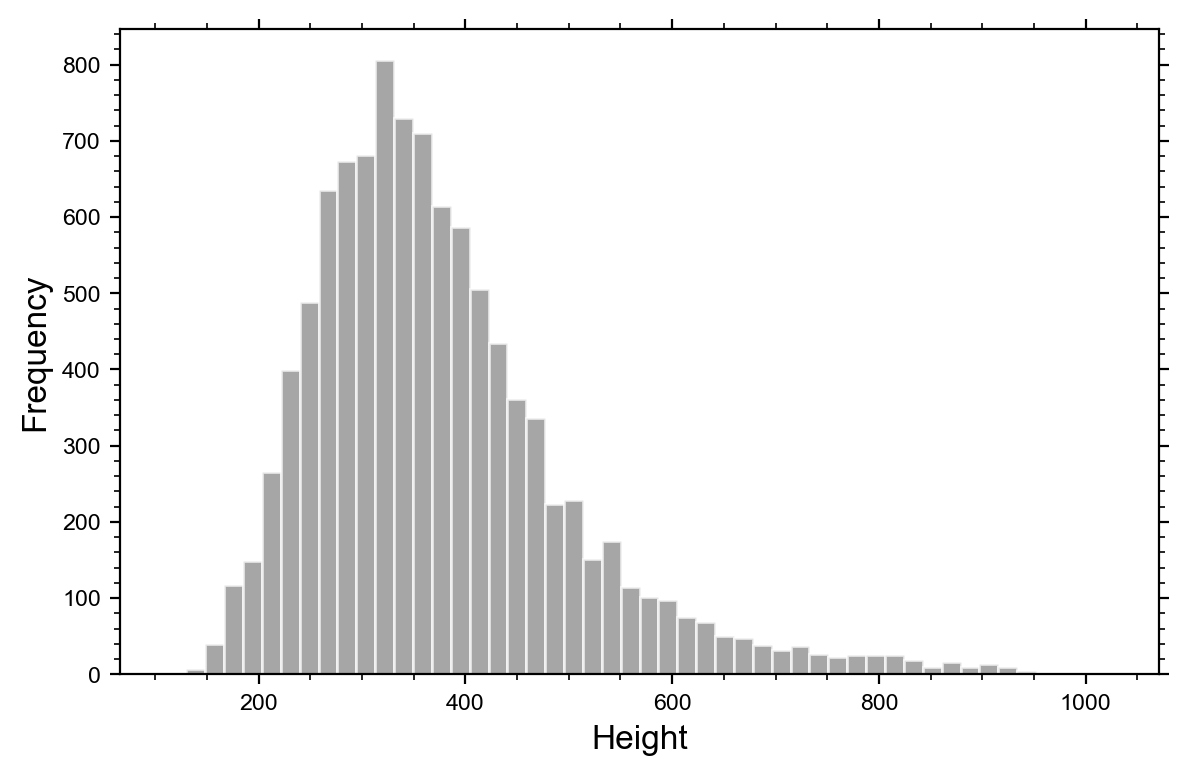

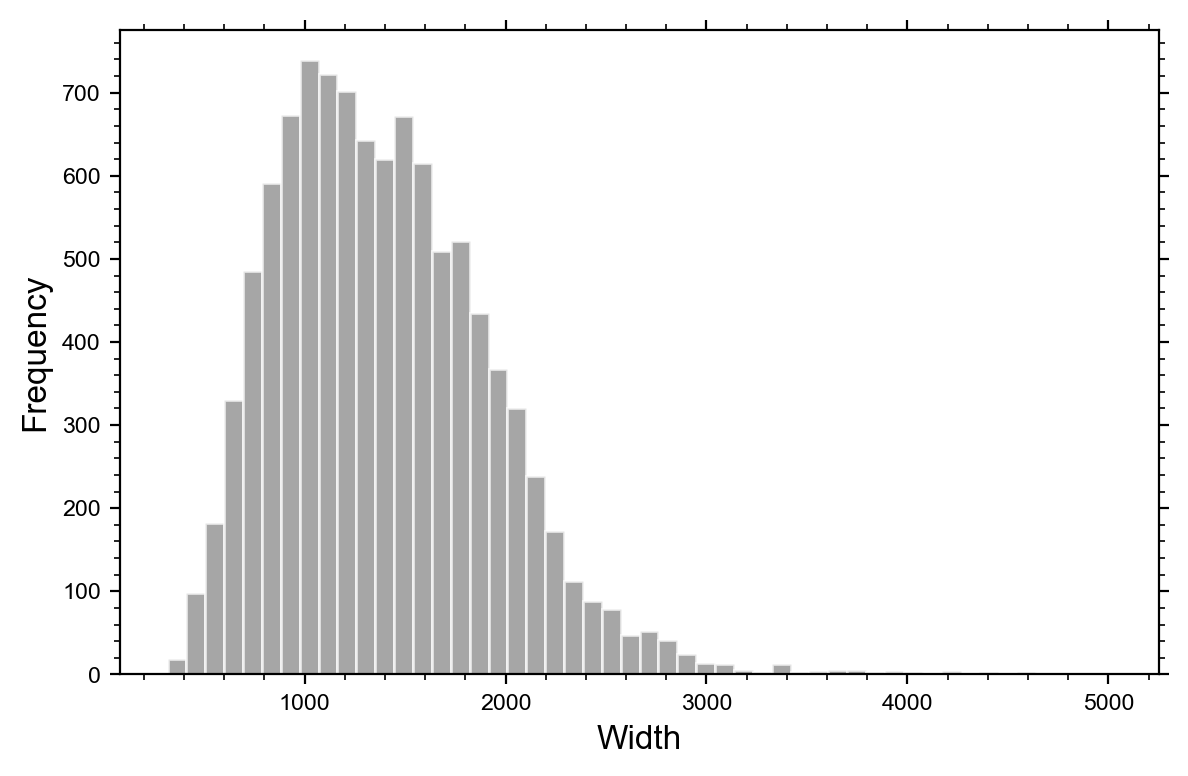

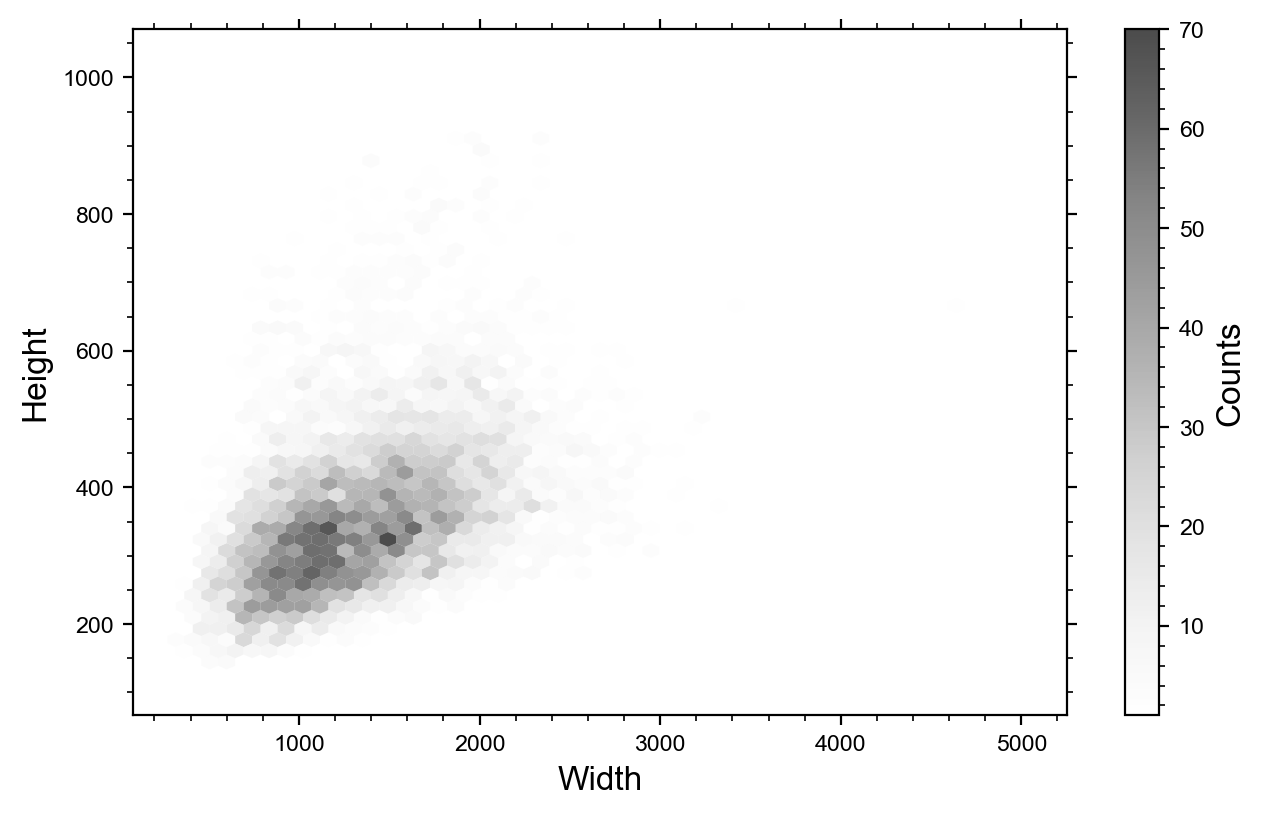

In [57]:
# Exploration of the DataFrame

# Height distribution
sample_fraction = 0.1
heights = images_exp.select("height") \
                  .sample(fraction = sample_fraction, seed = 42) \
                  .toPandas()["height"]
plt.hist(heights, bins = 50, edgecolor = "white", color = 'gray', alpha = 0.7)
# plt.title("Height Distribution")
plt.xlabel("Height")
plt.ylabel("Frequency")
plt.show()

# Width distribution
widths = images_exp.select("width"). \
                    sample(fraction = sample_fraction, seed = 42). \
                    toPandas()["width"]
plt.hist(widths, bins = 50, edgecolor = "white", color = 'gray', alpha = 0.7)
# plt.title("Width Distribution")
plt.xlabel("Width")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# Hex-bin / Scatter plot
plt.figure() 
hb = plt.hexbin(
    widths, 
    heights, 
    gridsize = 50,       
    mincnt = 1,          
    cmap = "Greys",      
    edgecolors = "none", 
    alpha = 0.7
)
plt.xlabel("Width")
plt.ylabel("Height")
# plt.title("Hexbin of Image Width vs. Height")
cb = plt.colorbar(hb)
cb.set_label("Counts")
plt.tight_layout()
plt.show()

In [51]:
visible_latex = images_exp.select("visible_latex_chars").sample(fraction = 0.1, seed = 42).toPandas()

all_visible_chars = [
    token
    for arr in visible_latex["visible_latex_chars"]
    for token in arr
]

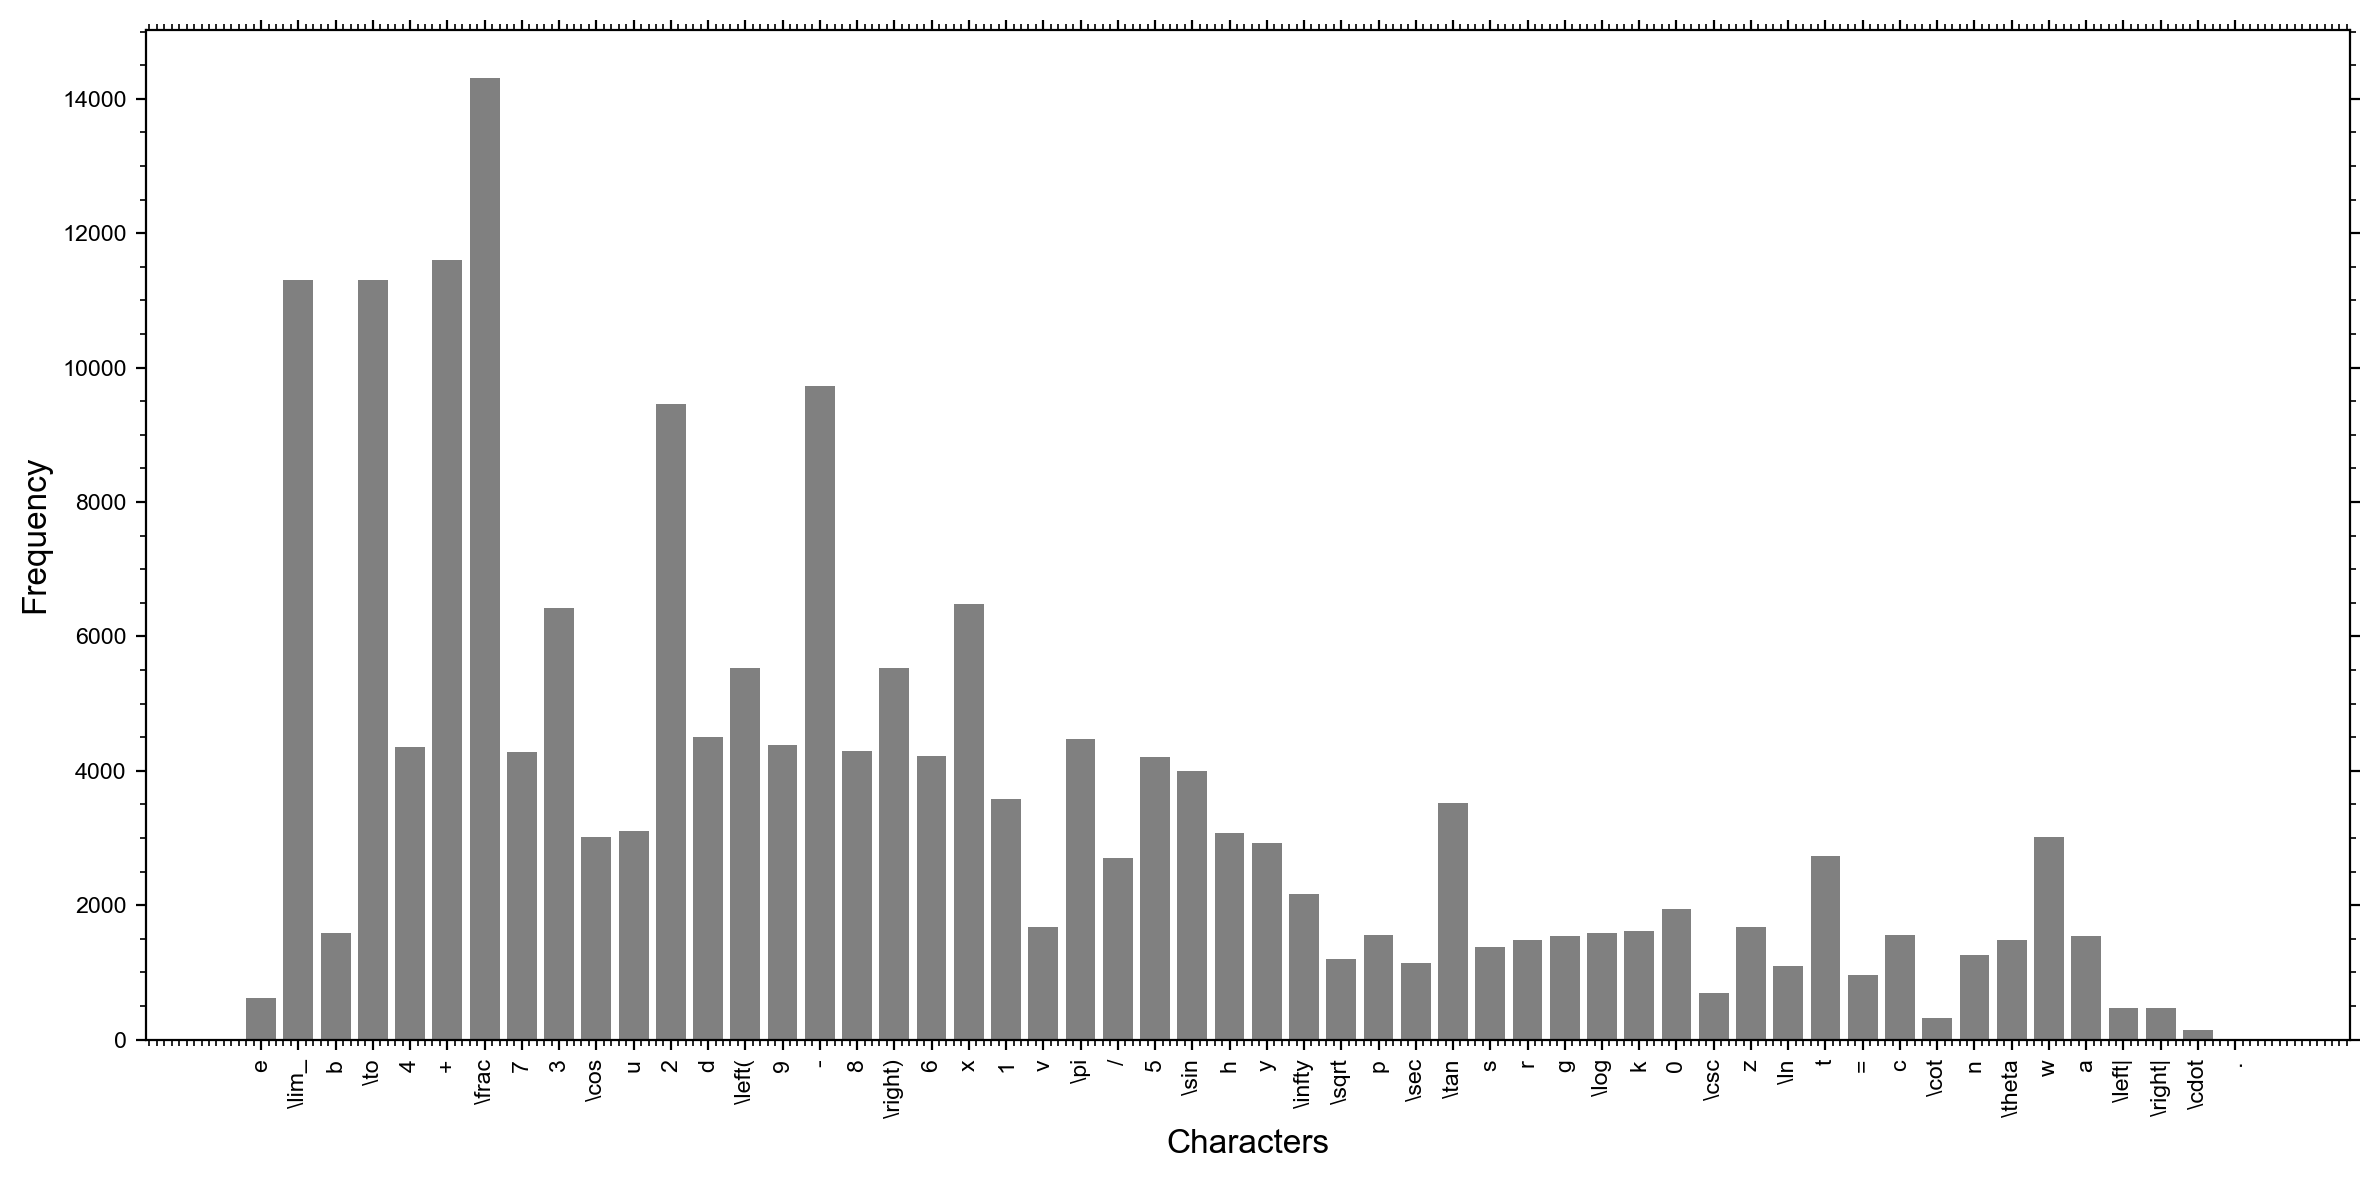

In [52]:
char_count = Counter(all_visible_chars)

chars = list(char_count.keys())
counts = list(char_count.values())

plt.figure(figsize = (12, 6))
plt.bar(chars, counts, color = "gray")
plt.xticks(rotation = 90)
plt.xlabel("Characters")
plt.ylabel("Frequency")
# plt.title("Frequency of Visible LaTeX Tokens")
plt.tight_layout()
plt.show()

In [ ]:
all_labels_df_small = images_exp.select("full_latex_chars").sample(fraction = 0.001, seed = 42).toPandas()

In [53]:
all_labels_df = images_exp.select("full_latex_chars").sample(fraction = 0.1, seed = 42).toPandas()

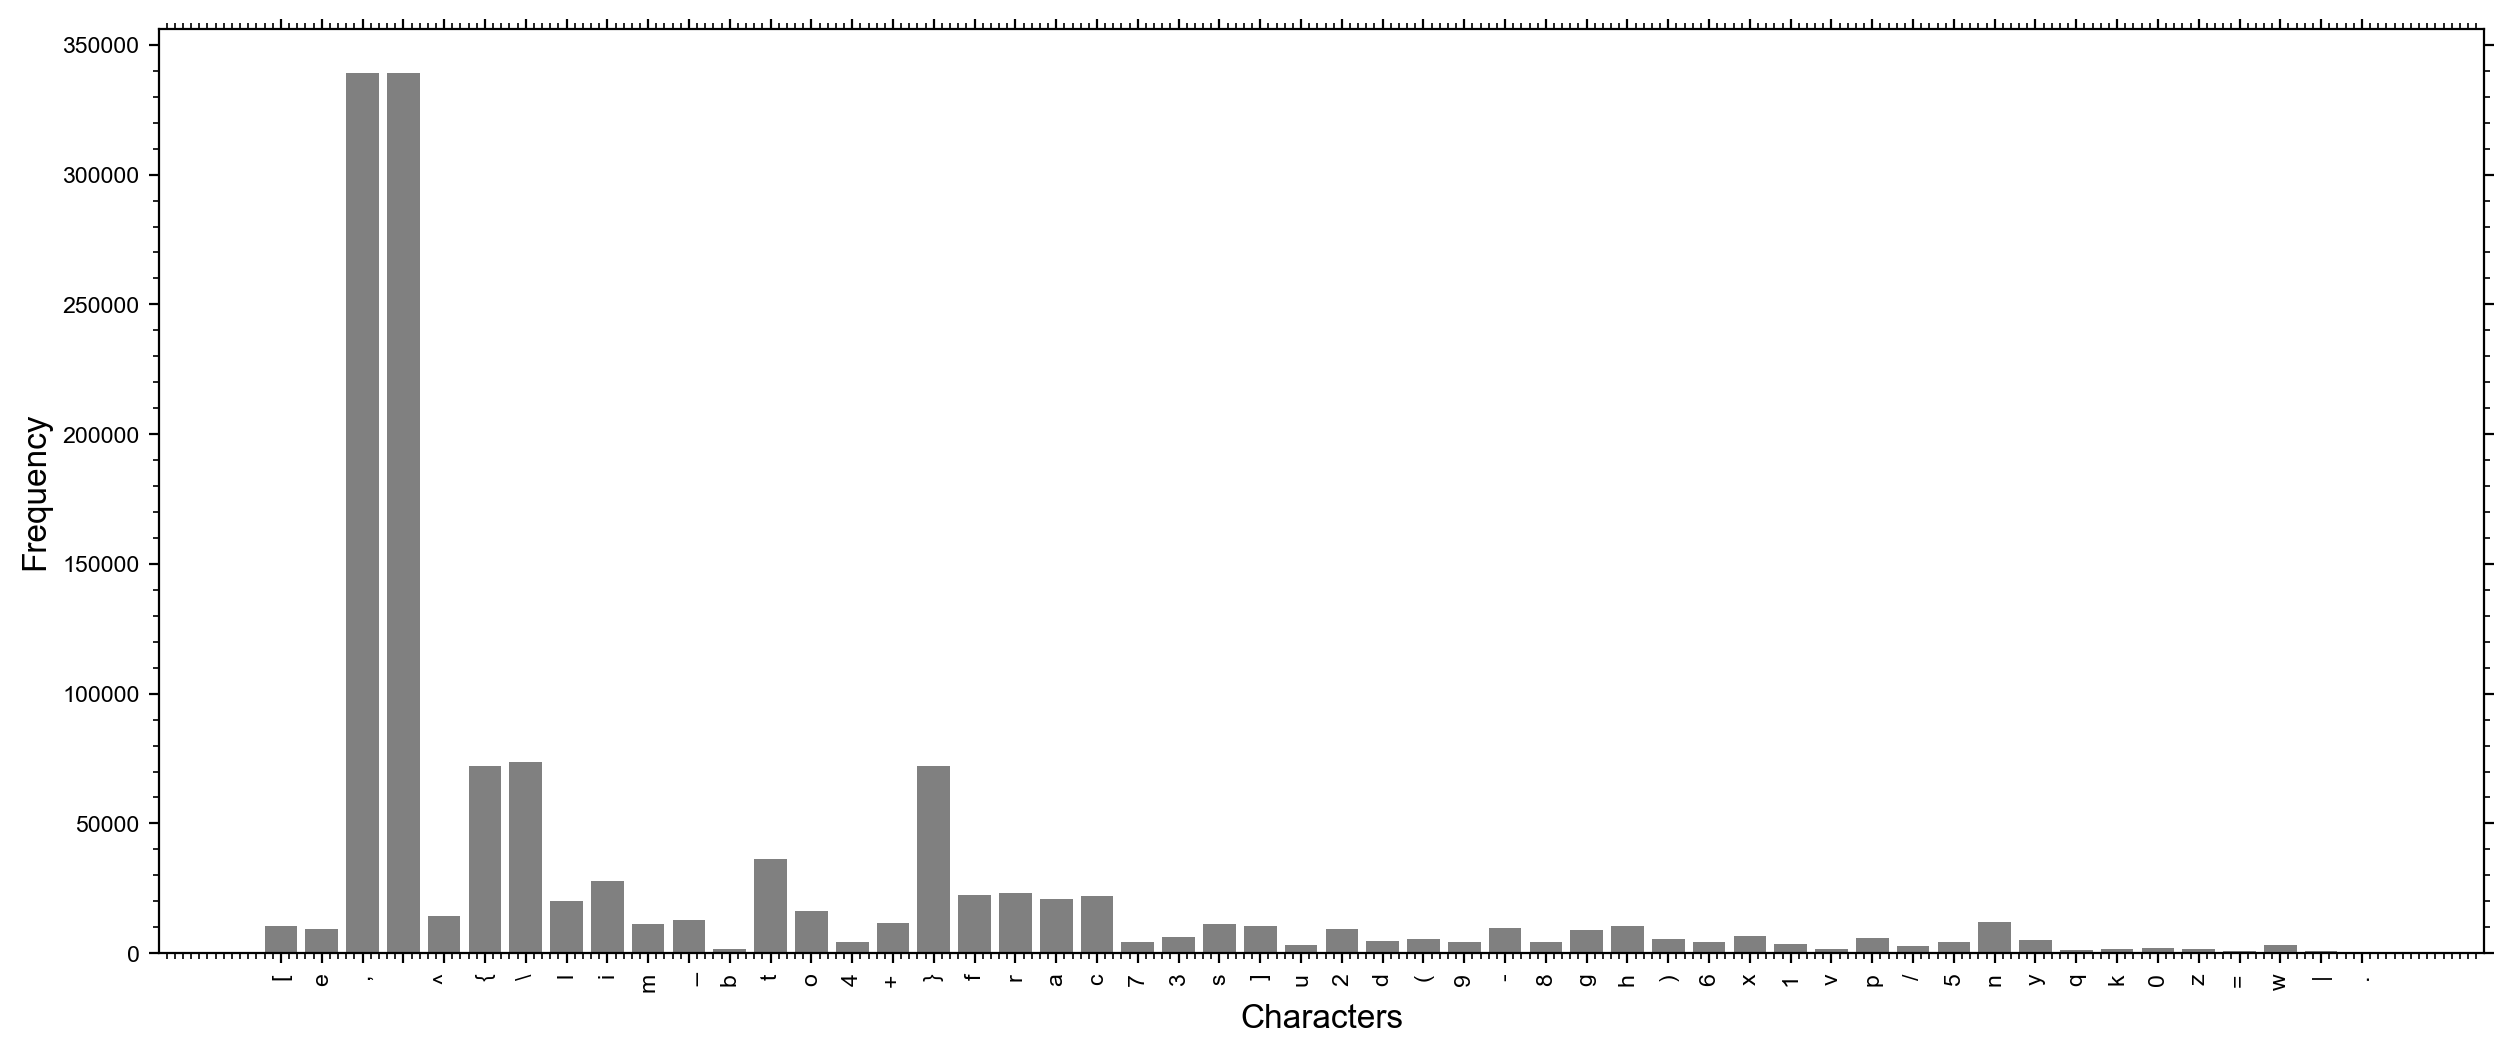

In [54]:
all_labels = [
    token
    for arr in all_labels_df["full_latex_chars"]
    for token in arr
]

label_count = Counter(all_labels)

lab_keys = label_count.keys()
lab_vals = label_count.values()



plt.figure(figsize = (15, 6))
plt.bar(lab_keys, lab_vals, color = "gray")
plt.xticks(rotation = 90)
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

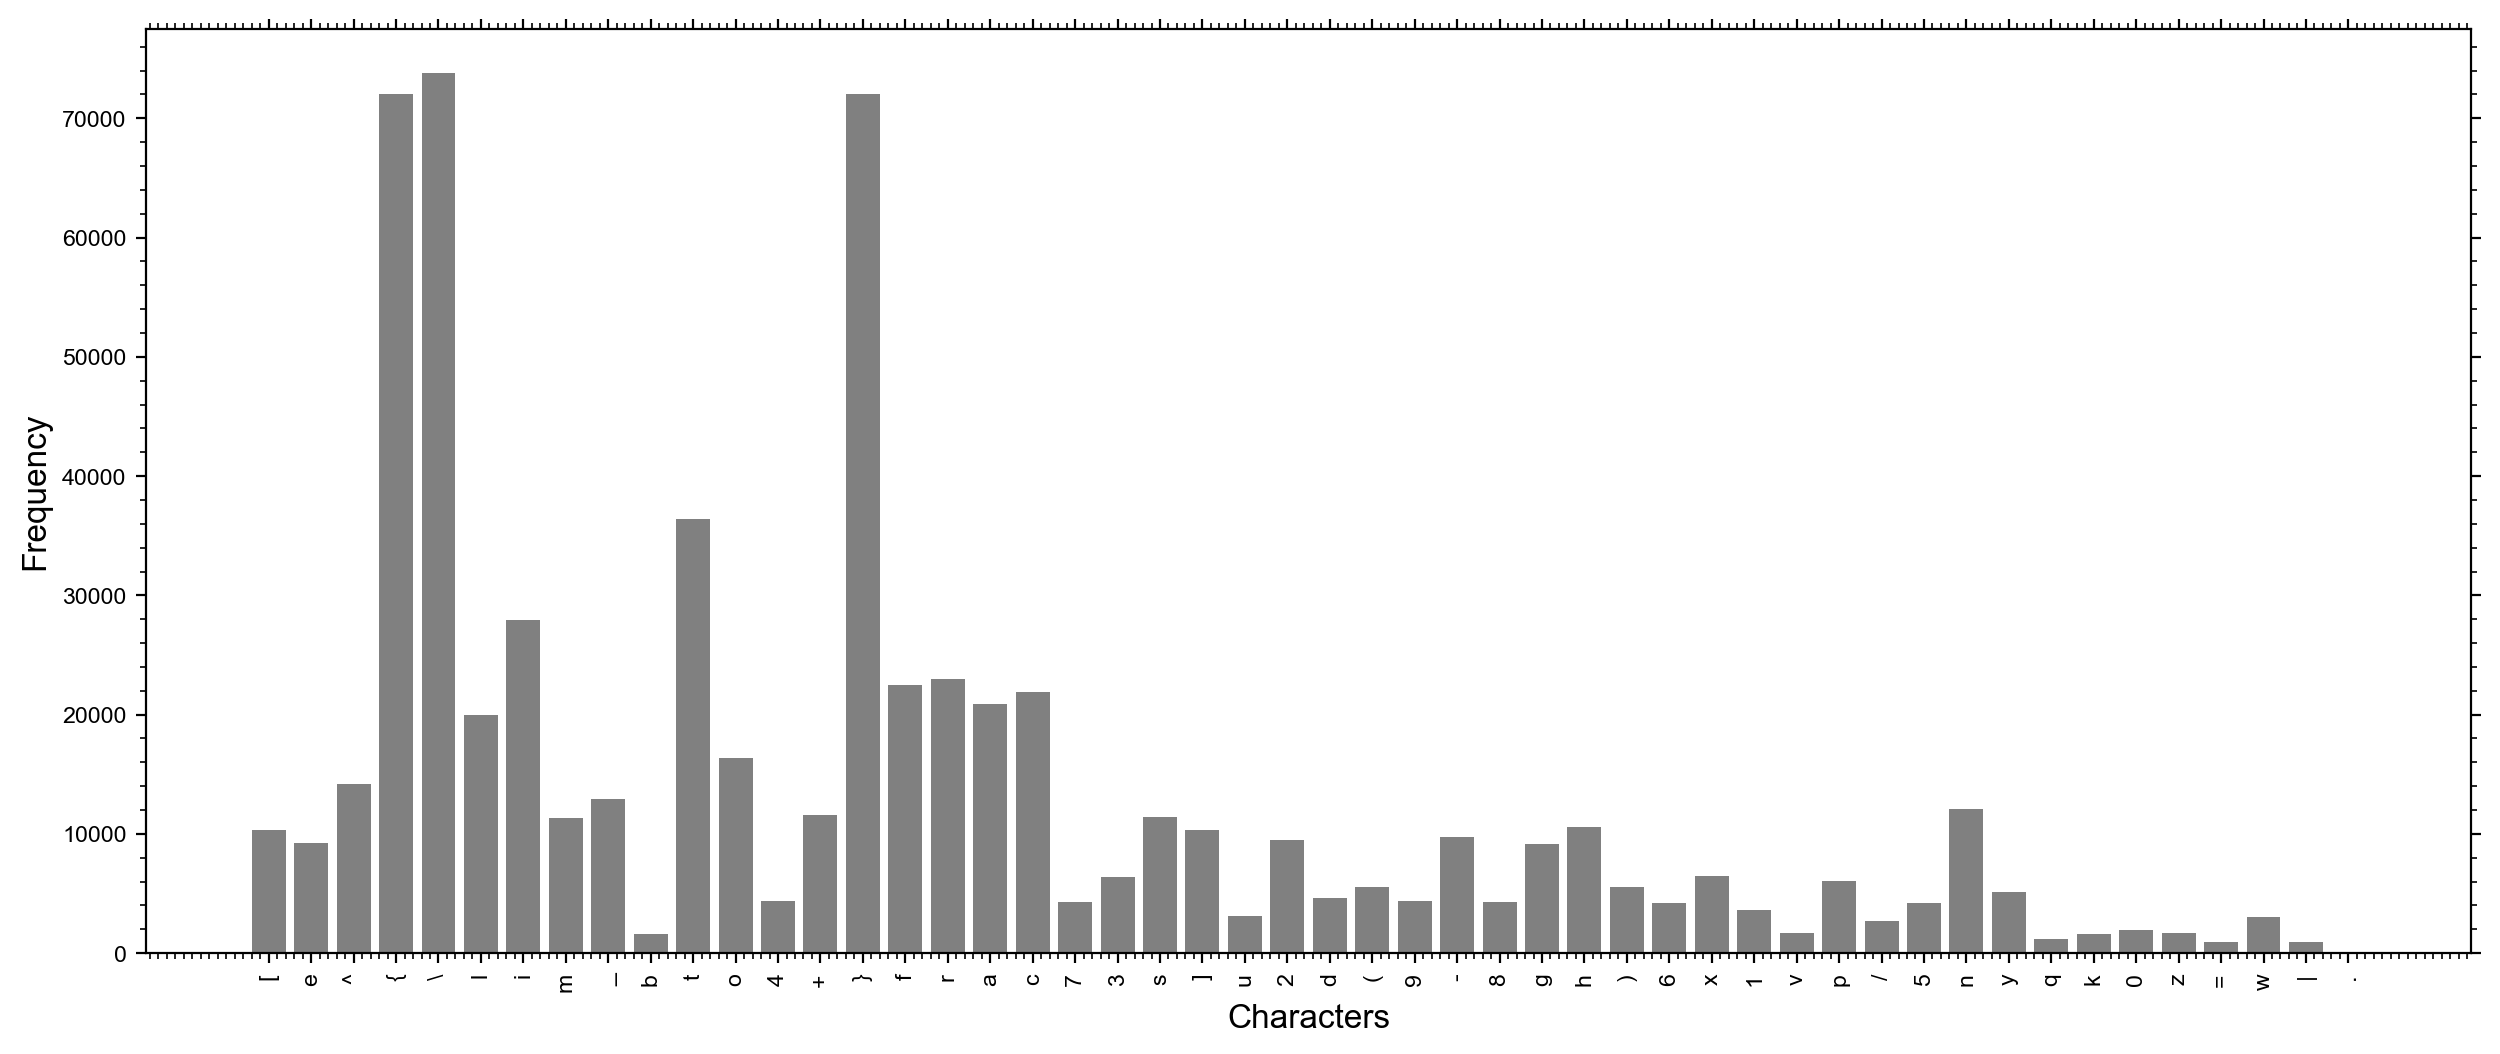

0

In [55]:
label_count.pop(",")
label_count.pop(" ")

lab_keys = label_count.keys()
lab_vals = label_count.values()

plt.figure(figsize = (15, 6))
plt.bar(lab_keys, lab_vals, color = "gray")
plt.xticks(rotation = 90)
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

label_count[","]

In [15]:
all_labels[:5]

['[', '\\', 'l', 'i', 'm']

In [ ]:
images_exp.show(3)

In [58]:
max_width = images_red.agg(max("width")).collect()[0][0]
min_width = images_red.agg(min("width")).collect()[0][0]
max_height = images_red.agg(max("height")).collect()[0][0]
min_height = images_red.agg(min("height")).collect()[0][0]
print(f"Max height: {max_height} \nMin height: {min_height} \nMax width: {max_width} \nMin width: {min_width}")

Max height: 1197.0 
Min height: 100.0 
Max width: 5340.0 
Min width: 259.0


In [7]:
# 1197.0 100.0 5340.0 259.0

In [18]:
images_small_dims = images_red.filter((col("width") <= 1000) & (col("height") <= 300))

In [19]:
images_small_dims.select("width", "height").show(5)
# print(images_small_dims.count())

+-----+------+
|width|height|
+-----+------+
|833.0| 239.0|
|730.0| 148.0|
|707.0| 294.0|
|787.0| 298.0|
|375.0| 215.0|
+-----+------+
only showing top 5 rows



In [10]:
# feature_model = load_model('models/symbol_model.keras')

In [11]:
# normalizing image inputs to the model

In [20]:
images_small_dims.coalesce(1).write.parquet("images_small_dims.parquet")
# images_small_dims.coalesce(1).write.format("parquet").save("data/images_small_dims.parquet")

In [12]:
temp = spark.read.parquet("images_small_dims.parquet")

temp.show(5)

+--------------------+--------------------+--------------------+--------------------+--------------------+-----+------+-----+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|            filename|               latex|    full_latex_chars| visible_latex_chars|    visible_char_map|width|height|depth|               xmins|               xmaxs|               ymins|               ymaxs|           xmins_raw|           xmaxs_raw|           ymins_raw|           ymaxs_raw|     true_file_paths|           png_masks|
+--------------------+--------------------+--------------------+--------------------+--------------------+-----+------+-----+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------